# NFCorpus RAG eval — visual analysis

Reads a run JSON from `_eval_/results/` and compares profiles via:

- mean metrics table
- Δ heatmap vs reference profiles
- winrate vs `baseline`
- ablation ladder
- per-query Δ distributions
- paired t-tests (needs `scipy` for p-values)
- `num_gold` vs recall diagnostic

Δ sign: **challenger − reference** (positive = challenger better).

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def find_repo_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "arg_config.yaml").is_file():
            return candidate
    raise FileNotFoundError("Could not locate repo root (arg_config.yaml)")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from _eval_.analysis import (
    delta_per_query,
    load_run_result,
    mean_delta_table,
    metric_names,
    paired_ttest,
    profile_map,
    winrate_matrix,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

# ── edit these ──
REF_PRODUCTION = "baseline"
REF_CHUNKER = "semantic"
PRIMARY_METRIC = "ndcg@10"
WINRATE_METRICS = ["ndcg@10", "mrr@20", "recall@10"]
ABLATION_ORDER = [
    "token",
    "semantic",
    "semantic_rerank",
    "baseline",
    "baseline_s2b",
    "baseline_hyde",
    "baseline_s2b_hyde",
    "baseline_predict_q",
    "full",
]
DELTA_PAIRS = [
    (REF_CHUNKER, "token"),
    (REF_CHUNKER, "semantic_rerank"),
    (REF_PRODUCTION, "semantic_rerank"),
    (REF_PRODUCTION, "baseline_s2b"),
    (REF_PRODUCTION, "baseline_hyde"),
    (REF_PRODUCTION, "baseline_predict_q"),
    (REF_PRODUCTION, "full"),
]

RESULTS_DIR = REPO_ROOT / "_eval_" / "results"
RUN_JSON = RESULTS_DIR / "nfcorpus_20260618T045954.json"

if not RUN_JSON.is_file():
    candidates = sorted(RESULTS_DIR.glob("nfcorpus_*.json"), reverse=True)
    if not candidates:
        raise FileNotFoundError(f"No nfcorpus run JSON under {RESULTS_DIR}")
    RUN_JSON = candidates[0]

print(f"repo: {REPO_ROOT}")
print(f"run:  {RUN_JSON.name}")

repo: c:\Users\JoeyC\Desktop\composer-agentic_rag
run:  nfcorpus_20260618T045954.json


In [2]:
run = load_run_result(RUN_JSON)
profiles = profile_map(run)
metrics = metric_names(run)

print(f"dataset: {run['dataset']}")
print(f"timestamp: {run['timestamp_utc']}")
print(f"profiles ({len(profiles)}): {', '.join(profiles)}")
print(f"queries: {run['results'][0]['num_queries']}")
print(f"config: {run['config']}")

dataset: nfcorpus
timestamp: 2026-06-18T04:59:54.419892+00:00
profiles (9): token, semantic, semantic_rerank, baseline, baseline_s2b, baseline_hyde, baseline_s2b_hyde, baseline_predict_q, full
queries: 50
config: {'profiles': ['token', 'semantic', 'semantic_rerank', 'baseline', 'baseline_s2b', 'baseline_hyde', 'baseline_s2b_hyde', 'baseline_predict_q', 'full'], 'k_values': [3, 10, 20], 'query_limit': 50, 'rel_threshold': 1, 'max_distractors_per_query': 100, 'predict_question_max_concurrency': 4, 'chunk_fetch_multiplier': 4, 'recreate': True}


## 1. Mean metrics (absolute)

In [3]:
mean_rows = []
for pid, prof in profiles.items():
    row = {"profile": pid, **prof["mean_metrics"]}
    row["docs"] = prof["num_docs_indexed"]
    mean_rows.append(row)

mean_df = pd.DataFrame(mean_rows).set_index("profile")
ordered = [p for p in ABLATION_ORDER if p in mean_df.index]
extra = [p for p in mean_df.index if p not in ordered]
mean_df = mean_df.loc[ordered + extra]

display(mean_df.round(3))

,recall@3,ndcg@3,hit@3,recall@10,ndcg@10,hit@10,recall@20,ndcg@20,hit@20,mrr@20,docs
profile,,,,,,,,,,,
token,0.139,0.593,0.80,0.222,0.509,0.90,0.279,0.472,0.94,0.792,1047
semantic,0.138,0.583,0.80,0.221,0.507,0.90,0.280,0.473,0.94,0.783,1047
semantic_rerank,0.139,0.582,0.80,0.203,0.469,0.86,0.249,0.434,0.88,0.750,1047
baseline,0.132,0.569,0.82,0.205,0.474,0.88,0.263,0.444,0.88,0.755,1047
baseline_s2b,0.130,0.555,0.82,0.203,0.465,0.88,0.260,0.436,0.88,0.745,1047
baseline_hyde,0.132,0.571,0.82,0.192,0.467,0.88,0.253,0.438,0.90,0.756,1047
baseline_s2b_hyde,0.131,0.562,0.82,0.204,0.470,0.88,0.263,0.444,0.88,0.745,1047
baseline_predict_q,0.143,0.584,0.82,0.206,0.478,0.88,0.265,0.451,0.88,0.755,1047
full,0.130,0.557,0.82,0.204,0.469,0.90,0.260,0.442,0.90,0.747,1047


## 2. Δ heatmap vs reference profiles

Left: vs `semantic` (chunker / reranker ladder). Right: vs `baseline` (production ablations).

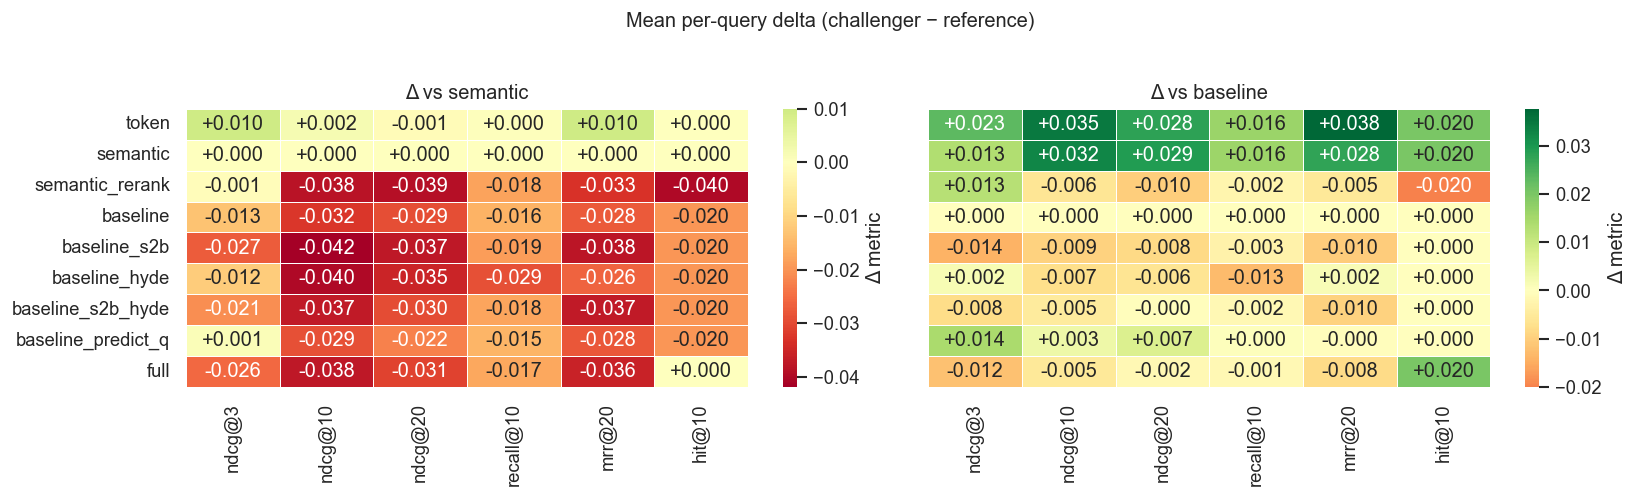

In [4]:
def delta_df(reference: str, metric_subset: list[str] | None = None) -> pd.DataFrame:
    metric_list = metric_subset or metrics
    table = mean_delta_table(
        run,
        reference_profile=reference,
        metrics=metric_list,
    )
    # mean_delta_table skips the reference; add a zero row so sharey heatmaps
    # keep the same y-axis labels and the reference shows as Δ=0.
    table[reference] = {m: 0.0 for m in metric_list}
    df = pd.DataFrame(table).T
    order = [p for p in ABLATION_ORDER if p in df.index]
    rest = [p for p in df.index if p not in order]
    return df.loc[order + rest]


focus_metrics = [m for m in ["ndcg@3", "ndcg@10", "ndcg@20", "recall@10", "mrr@20", "hit@10"] if m in metrics]

delta_sem = delta_df(REF_CHUNKER, focus_metrics)
delta_base = delta_df(REF_PRODUCTION, focus_metrics)

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, 0.45 * len(delta_sem))), sharey=True)
for ax, df, ref in [
    (axes[0], delta_sem, REF_CHUNKER),
    (axes[1], delta_base, REF_PRODUCTION),
]:
    sns.heatmap(
        df,
        annot=True,
        fmt="+.3f",
        cmap="RdYlGn",
        center=0,
        linewidths=0.5,
        ax=ax,
        cbar_kws={"label": "Δ metric"},
    )
    ax.set_title(f"Δ vs {ref}")
    ax.set_xlabel("")

fig.suptitle("Mean per-query delta (challenger − reference)", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 3. Winrate vs `baseline`

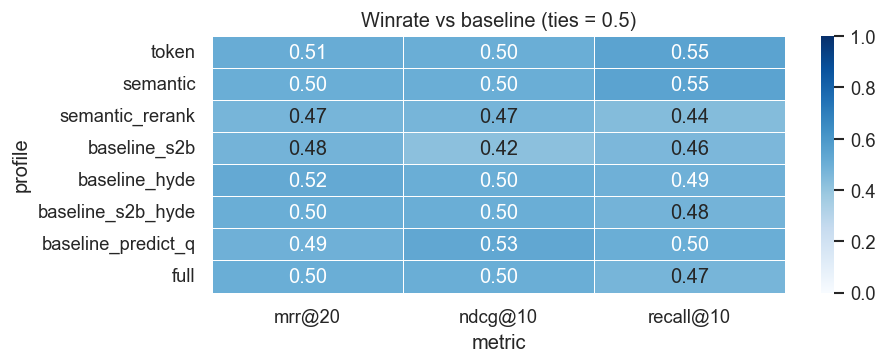

,profile,metric,winrate,wins,losses,ties
12,baseline_hyde,mrr@20,0.52,2,0,48
8,token,mrr@20,0.51,6,5,39
9,semantic,mrr@20,0.50,6,6,38
13,baseline_s2b_hyde,mrr@20,0.50,1,1,48
15,full,mrr@20,0.50,1,1,48
14,baseline_predict_q,mrr@20,0.49,0,1,49
11,baseline_s2b,mrr@20,0.48,0,2,48
10,semantic_rerank,mrr@20,0.47,2,5,43
6,baseline_predict_q,ndcg@10,0.53,5,2,43
0,token,ndcg@10,0.50,19,19,12


In [5]:
winrate_rows = []
for metric in WINRATE_METRICS:
    if metric not in metrics:
        continue
    matrix = winrate_matrix(run, reference_profile=REF_PRODUCTION, metric=metric)
    for pid, wr in matrix.items():
        winrate_rows.append(
            {
                "profile": pid,
                "metric": metric,
                "winrate": wr["winrate"],
                "wins": wr["wins"],
                "losses": wr["losses"],
                "ties": wr["ties"],
            }
        )

winrate_df = pd.DataFrame(winrate_rows)
if winrate_df.empty:
    print("No winrate data")
else:
    pivot = winrate_df.pivot(index="profile", columns="metric", values="winrate")
    order = [p for p in ABLATION_ORDER if p in pivot.index and p != REF_PRODUCTION]
    pivot = pivot.loc[order]

    fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(pivot))))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        ax=ax,
    )
    ax.set_title(f"Winrate vs {REF_PRODUCTION} (ties = 0.5)")
    plt.tight_layout()
    plt.show()

    display(winrate_df.sort_values(["metric", "winrate"], ascending=[True, False]).round(3))

## 4. Ablation ladder

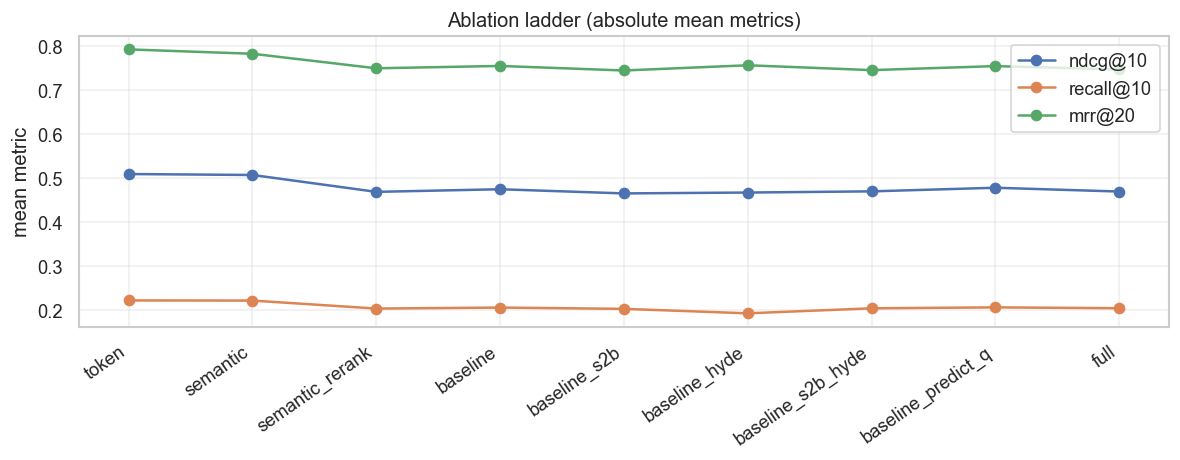

In [6]:
ladder_profiles = [p for p in ABLATION_ORDER if p in profiles]
ladder_metrics = [m for m in ["ndcg@10", "recall@10", "mrr@20"] if m in metrics]

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(ladder_profiles))
for metric in ladder_metrics:
    y = [profiles[p]["mean_metrics"][metric] for p in ladder_profiles]
    ax.plot(x, y, marker="o", label=metric)

ax.set_xticks(x)
ax.set_xticklabels(ladder_profiles, rotation=35, ha="right")
ax.set_ylabel("mean metric")
ax.set_title("Ablation ladder (absolute mean metrics)")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Per-query Δ distribution (selected pairs)

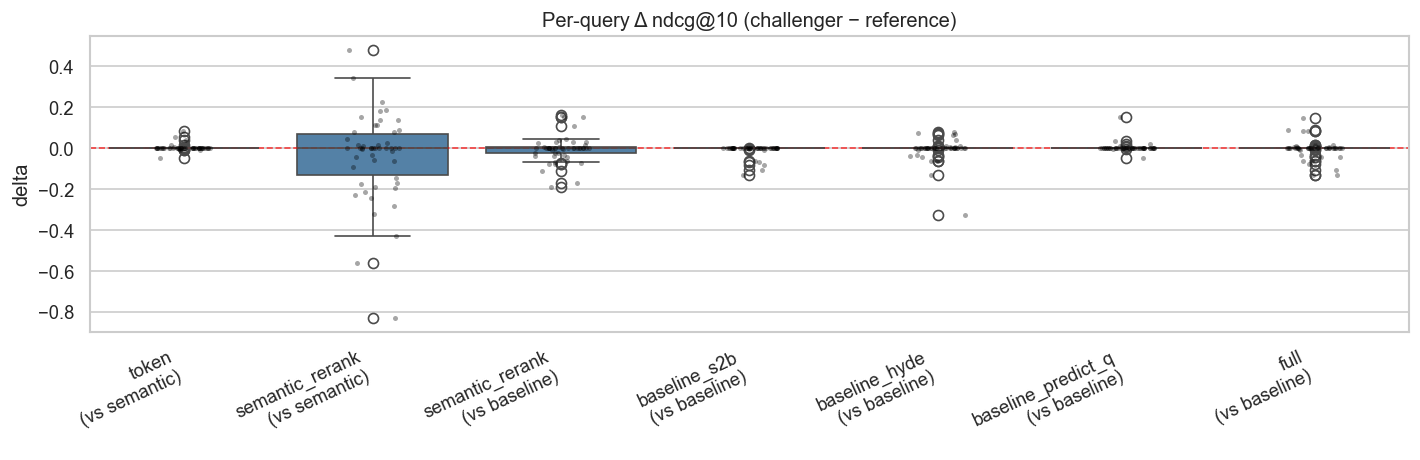

In [7]:
box_rows = []
for ref, challenger in DELTA_PAIRS:
    if ref not in profiles or challenger not in profiles:
        continue
    deltas = delta_per_query(
        run,
        reference_profile=ref,
        challenger_profile=challenger,
        metric=PRIMARY_METRIC,
    )
    label = f"{challenger}\n(vs {ref})"
    for qid, delta in deltas.items():
        box_rows.append({"pair": label, "delta": delta, "query_id": qid})

box_df = pd.DataFrame(box_rows)
if box_df.empty:
    print("No delta pairs to plot")
else:
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.boxplot(data=box_df, x="pair", y="delta", ax=ax, color="steelblue")
    sns.stripplot(
        data=box_df,
        x="pair",
        y="delta",
        ax=ax,
        color="black",
        alpha=0.35,
        size=3,
        jitter=0.15,
    )
    ax.axhline(0, color="red", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_title(f"Per-query Δ {PRIMARY_METRIC} (challenger − reference)")
    ax.set_xlabel("")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

## 6. Paired t-test (`baseline` ablations)

In [8]:
ttest_rows = []
for ref, challenger in DELTA_PAIRS:
    if ref not in profiles or challenger not in profiles:
        continue
    for metric in [PRIMARY_METRIC, "mrr@20"]:
        if metric not in metrics:
            continue
        tt = paired_ttest(
            run,
            reference_profile=ref,
            challenger_profile=challenger,
            metric=metric,
        )
        ttest_rows.append(
            {
                "reference": ref,
                "challenger": challenger,
                "metric": metric,
                "n": tt["n"],
                "mean_delta": tt["mean_delta"],
                "std_delta": tt["std_delta"],
                "t_stat": tt["t_statistic"],
                "p_value": tt["p_value"],
            }
        )

ttest_df = pd.DataFrame(ttest_rows)
if not ttest_df.empty:
    display(ttest_df.round(4))
    if ttest_df["p_value"].isna().all():
        print("Install scipy for p-values: pip install scipy")

,reference,challenger,metric,n,mean_delta,std_delta,t_stat,p_value
0,semantic,token,ndcg@10,50,0.0021,0.0166,0.9101,0.3672
1,semantic,token,mrr@20,50,0.0100,0.0707,0.9957,0.3243
2,semantic,semantic_rerank,ndcg@10,50,-0.0384,0.2127,-1.2766,0.2078
3,semantic,semantic_rerank,mrr@20,50,-0.0330,0.2757,-0.8467,0.4013
4,baseline,semantic_rerank,ndcg@10,50,-0.0060,0.0639,-0.6588,0.5131
5,baseline,semantic_rerank,mrr@20,50,-0.0053,0.1404,-0.2695,0.7887
6,baseline,baseline_s2b,ndcg@10,50,-0.0095,0.0290,-2.3137,0.0249
7,baseline,baseline_s2b,mrr@20,50,-0.0104,0.0707,-1.0358,0.3054
8,baseline,baseline_hyde,ndcg@10,50,-0.0075,0.0564,-0.9397,0.3520
9,baseline,baseline_hyde,mrr@20,50,0.0015,0.0081,1.3335,0.1885


## 7. Diagnostic: `num_gold` vs recall

High `num_gold` per query explains low absolute `recall@k` even when `hit@k` is high.

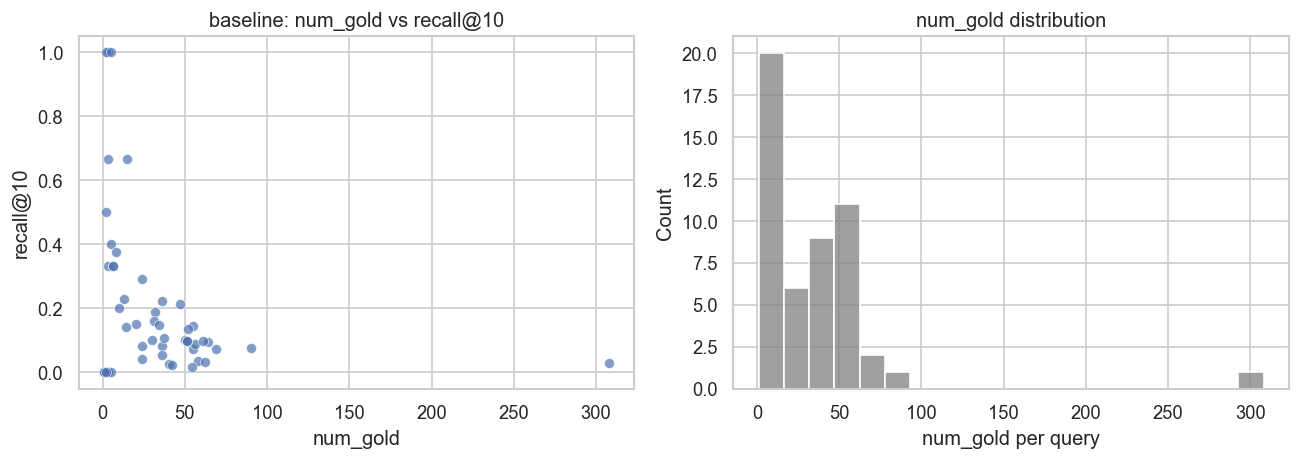

num_gold: median=30, mean=34.8, max=308


,num_gold,recall@10,hit@10
count,50.000,50.000,50.000
mean,34.780,0.205,0.880
std,45.789,0.256,0.328
min,1.000,0.000,0.000
25%,5.250,0.045,1.000
50%,30.500,0.100,1.000
75%,51.000,0.229,1.000
max,308.000,1.000,1.000


In [9]:
diag_metric = "recall@10" if "recall@10" in metrics else metrics[0]
ref_prof = profiles[REF_PRODUCTION]

diag_rows = [
    {
        "query_id": row["query_id"],
        "num_gold": row["num_gold"],
        diag_metric: row["metrics"][diag_metric],
        "hit@10": row["metrics"].get("hit@10"),
    }
    for row in ref_prof["per_query"]
]
diag_df = pd.DataFrame(diag_rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.scatterplot(data=diag_df, x="num_gold", y=diag_metric, ax=axes[0], alpha=0.7)
axes[0].set_title(f"{REF_PRODUCTION}: num_gold vs {diag_metric}")

sns.histplot(diag_df["num_gold"], bins=20, ax=axes[1], color="gray")
axes[1].set_title("num_gold distribution")
axes[1].set_xlabel("num_gold per query")

plt.tight_layout()
plt.show()

print(
    f"num_gold: median={diag_df['num_gold'].median():.0f}, "
    f"mean={diag_df['num_gold'].mean():.1f}, max={diag_df['num_gold'].max()}"
)
display(diag_df.describe().round(3))

## 8. Quick interpretation checklist

- **token ≈ semantic** on Δ heatmap → paragraph chunking likely inactive; check preflight / corpus `\n\n`.
- **semantic_rerank < semantic** → reranker may be hurting; inspect trace (B line) for rank drops.
- **baseline < semantic_rerank** → contextual not helping on this corpus.
- **Low recall + high hit** → many gold docs per query; prefer ndcg / MRR for profile comparison.
- **|mean Δ| < 0.01** on 50 queries → treat as noise until full 323-query run.